# 08 - Model Inference and Continuous Risk Mapping
In this notebook, we execute the final step of our machine learning pipeline: **Inference**.
We will:
1. Generate a uniform geographic grid (~300m resolution) across the entire Chikwawa district.
2. Extract the features (Topography, LandCover, NDVI, and Rainfall) simulating Cyclone Freddy (Mar 2023).
3. Preprocess the grid using our saved `scaler.pkl`.
4. Predict the exact flood probability for every point using our trained **XGBoost** model.
5. Generate a stunning, high-resolution Flood Risk Heatmap.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point, LineString
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
import osmnx as ox
import pickle
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
notebook_dir = Path(os.path.abspath(''))
project_root = notebook_dir.parent
data_dir = project_root / 'data'
raw_dir = data_dir / 'raw'
processed_dir = data_dir / 'processed'
models_dir = project_root / 'models'
figures_dir = project_root / 'figures'
figures_dir.mkdir(exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Generate Uniform Geographic Grid
We generate a dense grid over the district boundary. A resolution of 0.003 degrees corresponds to roughly 300 meters.

In [2]:
boundary_path = raw_dir / 'chikwawa_boundary.geojson'
chikwawa_gdf = gpd.read_file(boundary_path).to_crs('EPSG:4326')
district_geom = chikwawa_gdf.unary_union

# Resolution in degrees (0.003 is ~300m)
resolution = 0.003

print(f"Generating uniform grid at {resolution} degree resolution...")
minx, miny, maxx, maxy = district_geom.bounds
x_coords = np.arange(minx, maxx, resolution)
y_coords = np.arange(miny, maxy, resolution)

# Create a meshgrid
xx, yy = np.meshgrid(x_coords, y_coords)
points = [Point(x, y) for x, y in zip(xx.flatten(), yy.flatten())]
grid_gdf = gpd.GeoDataFrame(geometry=points, crs='EPSG:4326')

# Filter to keep only points inside the Chikwawa boundary
print(f"Total points generated in bounding box: {len(grid_gdf)}")
grid_gdf = grid_gdf[grid_gdf.geometry.within(district_geom)].reset_index(drop=True)
print(f"Points falling strictly inside Chikwawa: {len(grid_gdf)}")

Generating uniform grid at 0.003 degree resolution...


Total points generated in bounding box: 92247


Points falling strictly inside Chikwawa: 45898


## 2. Extract Geospatial Features
We will extract pixel values from our saved satellite `.tif` files. We use **Cyclone Freddy (Mar 2023)** as our target weather event to simulate severe risk conditions.

In [3]:
def sample_raster_at_points(tif_path, points_gdf, band=1):
    coords = [(row.geometry.x, row.geometry.y) for _, row in points_gdf.iterrows()]
    if not Path(tif_path).exists():
        print(f"WARNING: File {tif_path} not found.")
        return [np.nan] * len(coords)
    with rasterio.open(tif_path) as src:
        values = [x[0] if x[0] is not None else np.nan for x in src.sample(coords, indexes=band)]
    return values

# 1. Topography
topo_path = raw_dir / 'chikwawa_topography.tif'
print('Extracting Elevation and Slope...')
grid_gdf['Elevation_m'] = sample_raster_at_points(topo_path, grid_gdf, band=1)
grid_gdf['Slope_deg']   = sample_raster_at_points(topo_path, grid_gdf, band=2)

# 2. LandCover
lc_path = raw_dir / 'static' / 'landcover_esa2021.tif'
print('Extracting Land Cover...')
grid_gdf['LandCover'] = sample_raster_at_points(lc_path, grid_gdf, band=1)

# 3. Dynamic Features (Cyclone Freddy)
freddy_dir = raw_dir / 'events' / 'cyclone_freddy_mar2023'
print('Extracting Cyclone Freddy Rainfall and NDVI...')
grid_gdf['Rainfall_mm'] = sample_raster_at_points(freddy_dir / 'rainfall.tif', grid_gdf, band=1)
grid_gdf['NDVI'] = sample_raster_at_points(freddy_dir / 'ndvi.tif', grid_gdf, band=1)

print("Raster features extracted successfully.")

Extracting Elevation and Slope...


Extracting Land Cover...


Extracting Cyclone Freddy Rainfall and NDVI...


Raster features extracted successfully.


In [4]:
print('Calculating distance to Shire River (approximation)...')
import pyproj
from shapely.ops import transform

# Shire River main channel approximate centreline coordinates
shire_coords = [
    (34.55, -15.80), (34.60, -15.90), (34.65, -16.00),
    (34.70, -16.10), (34.75, -16.20), (34.80, -16.30),
    (34.85, -16.40), (34.90, -16.50), (34.95, -16.60),
]
shire_line = LineString(shire_coords)

# Project to UTM 36S for metre-based distance
proj = pyproj.Transformer.from_crs('EPSG:4326', 'EPSG:32736', always_xy=True).transform
shire_proj = transform(proj, shire_line)
grid_proj = grid_gdf.to_crs('EPSG:32736')
grid_gdf['Dist_River_m'] = grid_proj.geometry.distance(shire_proj)

print(f'Done. Distance range: {grid_gdf["Dist_River_m"].min():.0f}m - {grid_gdf["Dist_River_m"].max():.0f}m')

Calculating distance to Shire River (approximation)...
Done. Distance range: 3m - 34087m


In [5]:
print('Applying custom feature engineering...')
# Forward-fill any NaN values safely
grid_gdf = grid_gdf.fillna(method='ffill').fillna(method='bfill')

# 1. Slope adjustment and indices
grid_gdf['Slope_deg'] = grid_gdf['Slope_deg'].replace(0.0, 1.0)
grid_gdf['topographic_wet_index'] = grid_gdf['Rainfall_mm'] / grid_gdf['Slope_deg']
grid_gdf['elevation_to_river'] = grid_gdf['Elevation_m'] / (grid_gdf['Dist_River_m'] + 1.0)

# 2. LandCover mapping to names, then to LC_codes
LANDCOVER_LABELS = {
    10: 'Forest', 20: 'Shrubland', 30: 'Grassland',
    40: 'Cropland', 50: 'Built-Up', 60: 'Bare Land',
    80: 'Water Body', 90: 'Wetland'
}
grid_gdf['LandCover_Name'] = grid_gdf['LandCover'].map(LANDCOVER_LABELS)

lc_code_map = {
    'Bare Land': 0, 'Built-Up': 1, 'Cropland': 2, 'Forest': 3, 
    'Grassland': 4, 'Shrubland': 5, 'Water Body': 6, 'Wetland': 7
}
grid_gdf['LC_codes'] = grid_gdf['LandCover_Name'].map(lc_code_map).fillna(0) # Default to 0 if NaN

# 3. Permeability Scoring and PS_codes
permeab = {
    "high": [10],
    "moderate": [20, 30, 40],
    "low": [50, 60, 70, 80, 90]
}
landcover_to_permeab = {lc: score for score, lcs in permeab.items() for lc in lcs}
grid_gdf['permeability_score'] = grid_gdf['LandCover'].map(landcover_to_permeab)

ps_code_map = {'high': 0, 'low': 1, 'moderate': 2}
grid_gdf['PS_codes'] = grid_gdf['permeability_score'].map(ps_code_map).fillna(2) # Default to moderate if NaN

FEATURE_COLS = [
    'Elevation_m', 'Slope_deg', 'NDVI', 'Rainfall_mm', 'Dist_River_m', 
    'topographic_wet_index', 'elevation_to_river', 'LC_codes', 'PS_codes'
]

X_infer = grid_gdf[FEATURE_COLS].copy()
print(f"Inference Data Shape: {X_infer.shape}")

Applying custom feature engineering...


Inference Data Shape: (45898, 9)


## 3. Data Preprocessing
We load the `scaler.pkl` to scale the inference data.

In [6]:
scaler_path = processed_dir / 'scaler.pkl'
print("Loading StandardScaler...")
with open(scaler_path, 'rb') as f:
    scaler = pickle.load(f)

# Scale
X_scaled = scaler.transform(X_infer)
print("Features scaled successfully.")

Loading StandardScaler...
Features scaled successfully.


## 4. Model Prediction
We load the `xgb_model.pkl` to predict probabilities.

In [7]:
model_path = models_dir / 'xgb_model.pkl'
print("Loading XGBoost Model...")
with open(model_path, 'rb') as f:
    model = pickle.load(f)

print("Running Inference (predict_proba)...")
y_prob = model.predict_proba(X_scaled)[:, 1]

# Append predictions back to the grid GeoDataFrame
grid_gdf['Flood_Risk_Prob'] = y_prob
grid_gdf['Risk_Percentage'] = y_prob * 100

print(f"Mean Flood Risk: {grid_gdf['Risk_Percentage'].mean():.2f}%")
print(f"Max Flood Risk: {grid_gdf['Risk_Percentage'].max():.2f}%")

Loading XGBoost Model...


Running Inference (predict_proba)...
Mean Flood Risk: 0.87%
Max Flood Risk: 94.04%


## 5. Generate Flood Risk Heatmap
Visualizing the continuous probabilities spatially.

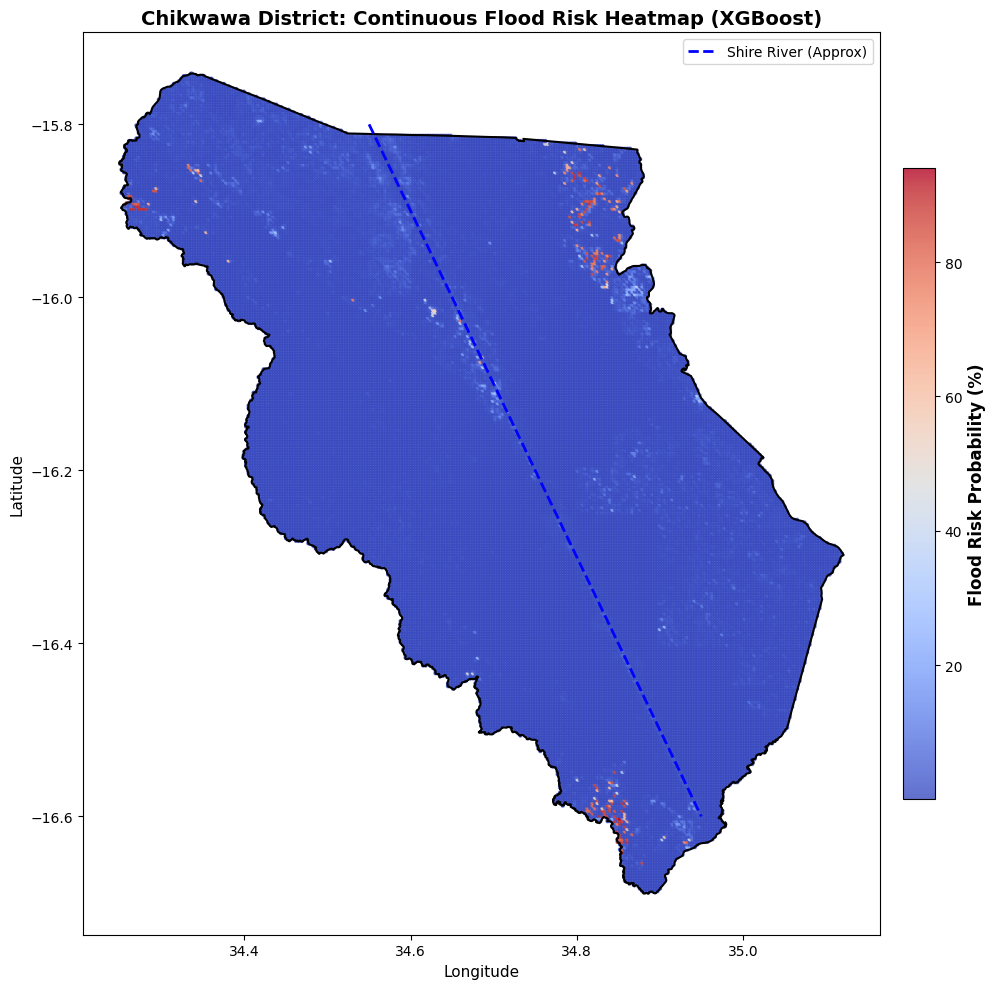

In [8]:
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the district boundary
chikwawa_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5, zorder=2)

# Plot the grid probabilities
scatter = ax.scatter(
    grid_gdf.geometry.x, 
    grid_gdf.geometry.y, 
    c=grid_gdf['Risk_Percentage'], 
    cmap='coolwarm', 
    s=5, 
    alpha=0.8,
    zorder=1
)

# Colorbar formatting
cbar = plt.colorbar(scatter, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Flood Risk Probability (%)', fontsize=12, weight='bold')

plt.title('Chikwawa District: Continuous Flood Risk Heatmap (XGBoost)', fontsize=14, weight='bold')
plt.xlabel('Longitude', fontsize=11)
plt.ylabel('Latitude', fontsize=11)
plt.grid(False)

# Add Shire River to map
shire_line_gdf = gpd.GeoDataFrame(geometry=[shire_line], crs='EPSG:4326')
shire_line_gdf.plot(ax=ax, color='blue', linewidth=2, linestyle='--', label='Shire River (Approx)')
plt.legend()

plt.tight_layout()
plt.savefig(figures_dir / 'final_flood_risk_heatmap.png', dpi=300)
plt.show()